# Comparação de Tempo, Energia e Memória dos 3 algoritmos
Importando a biblioteca pandas e matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Carregando o CSV

In [2]:
df = pd.read_csv("../Resultados preliminares/10000000.csv")

# Visualizar primeiras linhas
print(df.head())

    vector_type algorithm      size  time_ms  stress  ram_kb_max  \
0      endnoise  HeapSort  10000000  4490.67     NaN       42944   
1       ordered  HeapSort  10000000  3942.80     NaN       42948   
2  random_swaps  HeapSort  10000000  4109.08     NaN       42944   
3        random  HeapSort  10000000  6796.72     NaN       42904   
4  repeated_1_5  HeapSort  10000000  3393.87     NaN       42900   

   ram_kb_media  energy_j  
0         42811  111.3100  
1         42815  150.0890  
2         42811  148.3980  
3         42771  229.0000  
4         42767   92.8636  


# Gráfico dos tempos médios

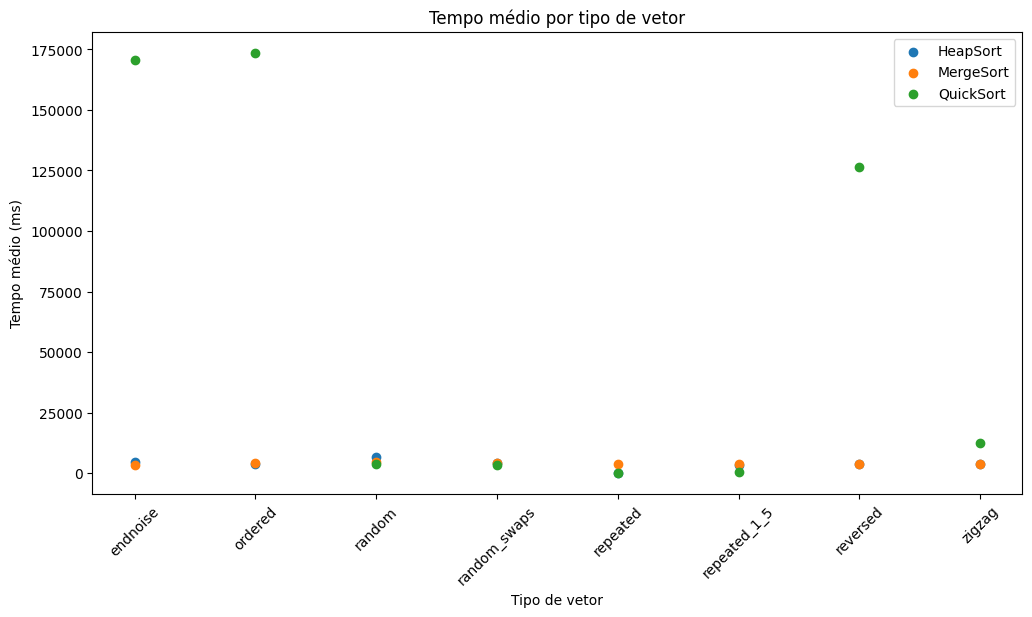

In [4]:
plt.figure(figsize=(12, 6))

#Obter os algoritmos únicos
algorithms = df["algorithm"].unique()

for alg in algorithms:
    dados = (
        df[df["algorithm"] == alg]
        .groupby("vector_type")["time_ms"]
        .mean()
        .sort_index()
    )

    plt.scatter(dados.index, dados.values, label=alg)

plt.xlabel("Tipo de vetor")
plt.ylabel("Tempo médio (ms)")
plt.title("Tempo médio por tipo de vetor")

plt.xticks(rotation=45)
plt.legend()

plt.show()

# Gráfico por Energia Média

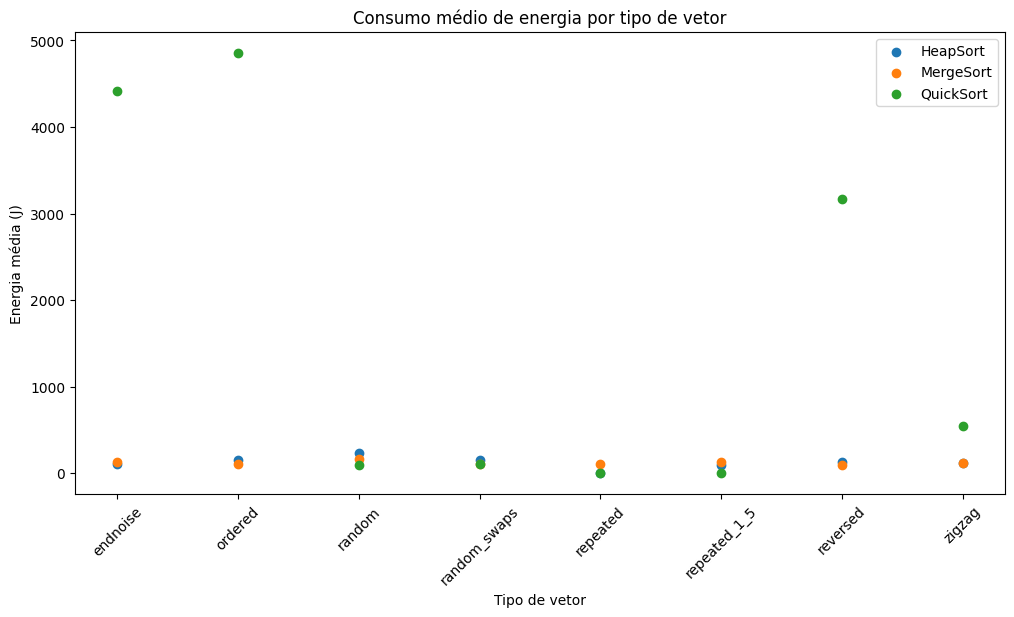

In [5]:
plt.figure(figsize=(12, 6))

for alg in algorithms:
    dados = (
        df[df["algorithm"] == alg]
        .groupby("vector_type")["energy_j"]
        .mean()
        .sort_index()
    )

    plt.scatter(dados.index, dados.values, label=alg)

plt.xlabel("Tipo de vetor")
plt.ylabel("Energia média (J)")
plt.title("Consumo médio de energia por tipo de vetor")

plt.xticks(rotation=45)
plt.legend()

plt.show()

# Gráfico de Memória RAM Média

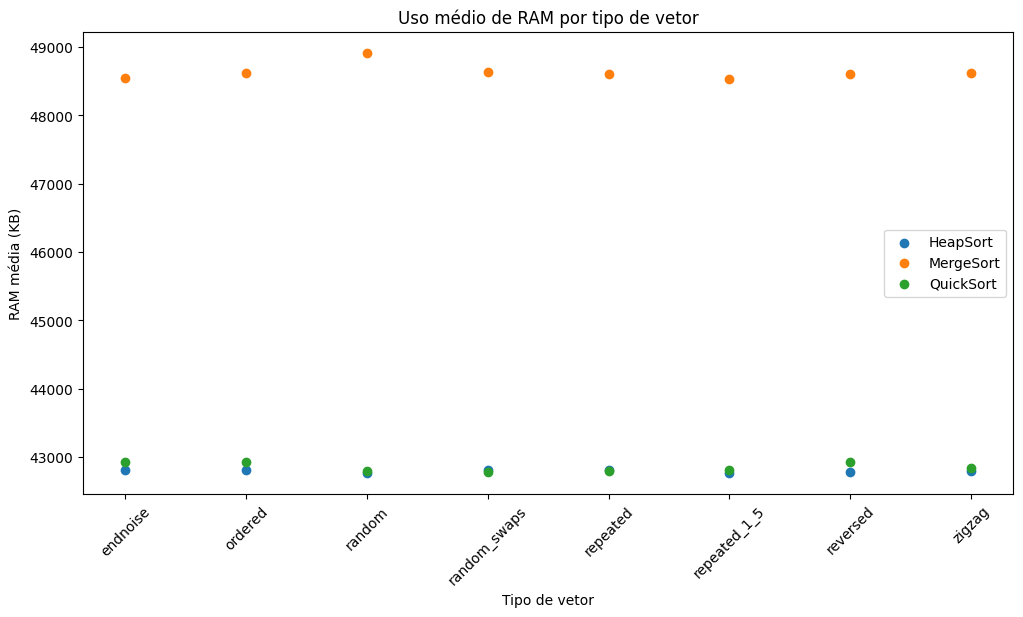

In [6]:
plt.figure(figsize=(12, 6))

for alg in algorithms:
    dados = (
        df[df["algorithm"] == alg]
        .groupby("vector_type")["ram_kb_media"]
        .mean()
        .sort_index()
    )

    plt.scatter(dados.index, dados.values, label=alg)

plt.xlabel("Tipo de vetor")
plt.ylabel("RAM média (KB)")
plt.title("Uso médio de RAM por tipo de vetor")

plt.xticks(rotation=45)
plt.legend()

plt.show()

Foi verificado que ambas energia e tempo parecem possuir forte correlação, ou seja, quanto mais tempo um algoritmo leva, mais energia ele usa. Foi então testado esta hipótese

# Correlação numérica

In [7]:
correlacao = df[["time_ms", "energy_j"]].corr()

print(correlacao)

           time_ms  energy_j
time_ms   1.000000  0.998175
energy_j  0.998175  1.000000


# Correlação por algoritmo

In [8]:
for alg in algorithms:
    subset = df[df["algorithm"] == alg]

    corr = subset[["time_ms", "energy_j"]].corr().iloc[0, 1]

    print(f"{alg}: {corr}")

HeapSort: 0.954260393484494
MergeSort: 0.5089430474671888
QuickSort: 0.9975581892315861
